# lrdata to MuData

### Load packages

In [1]:
from pathlib import Path
import scanpy as sc
import squidpy as sq
import liana as li
import pandas as pd
import os

/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(
/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/xarray_schema/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/spatialdata/_core/query/relational_query.py:530: FutureWarning: functools.partial will be a method descriptor in future Python versions;

## Load and Prep Data

In [2]:
# file_path = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
# backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

# if os.path.exists(file_path):
#     adata = sc.read(file_path)
# else:
#     adata = sc.read(
#     file_path,
#     backup_url=backup_url
# )

# adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# adata.var_names = adata.var["gene_name"]
# adata.obsm['spatial'] = adata.obsm['X_spatial_coords']

In [3]:
# data_path = Path("data/agne_cd/")
# adata = sc.read_h5ad(data_path / "RUN1_SLIDE2_S6.h5ad")

# adata.obsm['spatial'] = adata.obs[['x', 'y']].to_numpy()

# adata.obs['cell_type'] = adata.obs['CellAnnotation.Level0']

In [4]:
adata = sc.read("data/kuppe_heart19.h5ad", backup_url='https://figshare.com/ndownloader/files/41501073?private_link=4744950f8768d5c8f68c')
adata.obs['cell_type'] = adata.obs['celltype_niche']

In [5]:
adata.layers['counts'] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

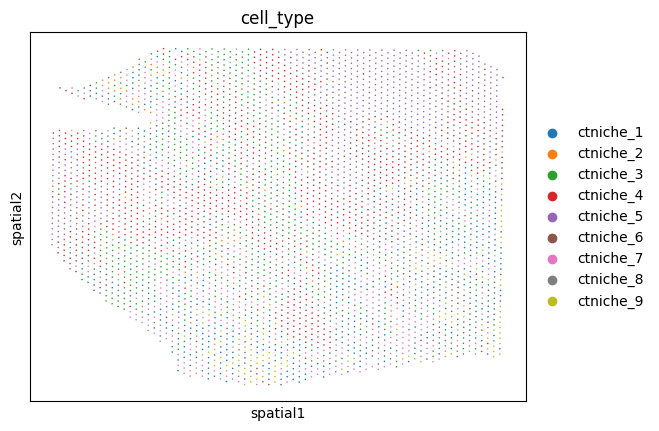

In [6]:
sc.pl.embedding(adata, basis="spatial", color=["cell_type"], wspace=0.4, s= 5)

Use the chosen bandwidth based on this exploration to compute the final spatial connectivity matrix $W_{ij}$.

In [7]:
li.ut.spatial_neighbors(adata=adata, bandwidth=200)

#### Visualize proximity

/g/stegle/ddimitro/repos/liana-py/src/liana/plotting/_connectivity_plot.py:38: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.


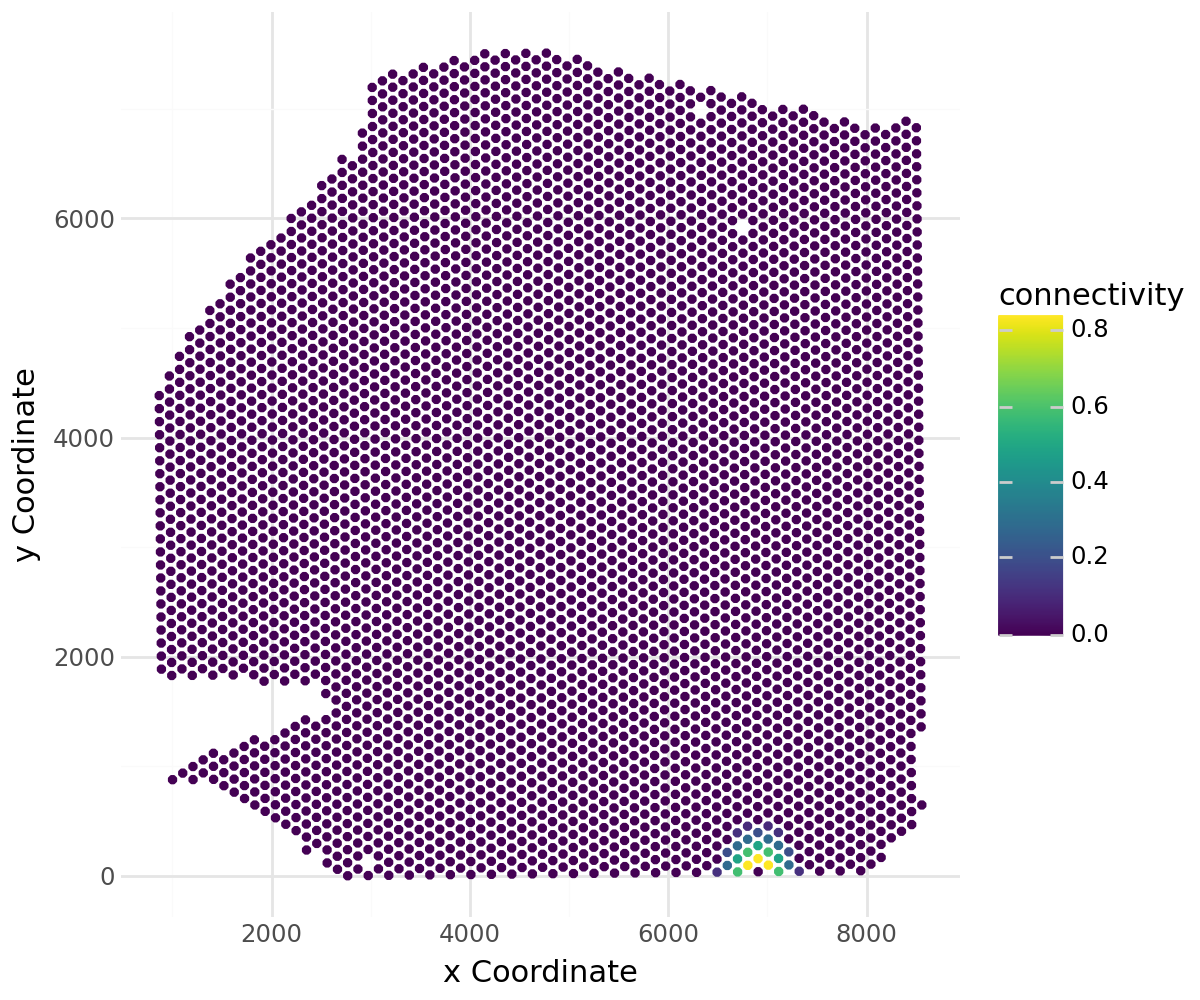

In [8]:
li.pl.connectivity(adata, idx=1000, size=1, figure_size=(6, 5))

### Find spatially variable genes (SVGs) using Morans'I

In [9]:
sq.gr.spatial_autocorr(adata, mode='moran', use_raw=False, show_progress_bar=True)

In [10]:
adata.uns['moranI']
#I: Moran’s I score for each gene
#pval: p-value (if permutation test is used)
#var_norm: Variance used to normalize Moran’s I (used internally for significance).
#pval_norm_fdr_bh: FDR-adjusted p-value (Benjamini-Hochberg correction) for multiple testing.

,I,pval_norm,var_norm,pval_norm_fdr_bh
DES,0.769688,0.000000,0.000016,0.000000
MYL2,0.756740,0.000000,0.000016,0.000000
MYH6,0.747948,0.000000,0.000016,0.000000
TPM1,0.737534,0.000000,0.000016,0.000000
TNNC1,0.734646,0.000000,0.000016,0.000000
...,...,...,...,...
AC093297.2,-0.009878,0.007852,0.000016,0.020998
AP4M1,-0.009879,0.007845,0.000016,0.020985
AKR1E2,-0.009983,0.007299,0.000016,0.019701
WDFY2,-0.010201,0.006266,0.000016,0.017201


### Filter by spatially variable genes (SVGs)

In [11]:
## Check how many spatially variable genes (SVGs)
svgs = adata.uns['moranI'].index[(adata.uns['moranI']['pval_norm_fdr_bh'] < 0.05) & (adata.uns['moranI']['I'] > 0.01)]
len(svgs)

6301

In [12]:
adata = adata[:, svgs]

## Compute inflow score 

#### Get LR database

- **Mouse**? Convert LR database to mouse gene symbol

In [13]:
lrdata = li.mt.inflow(adata,
                      groupby='cell_type',
                      resource_name='consensus',
                      use_raw=False)
                                  
lrdata.shape

/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/g/stegle/ddimitro/repos/liana-py/src/liana/method/sp/_inflow.py:318: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.


(4113, 10257)

### Optional: filter data to keep only spatially variable LR interaction

In [14]:
sq.gr.spatial_autocorr(lrdata, mode='moran', use_raw=False)

In [15]:
svis = lrdata.uns['moranI'].index[(lrdata.uns['moranI']['pval_norm_fdr_bh'] <= 0.05) & (lrdata.uns['moranI']['I'] > 0.01)]
len(svis)

9900

In [16]:
lrdata = lrdata[:,svis]
lrdata.uns['moranI'].sort_values("I").tail(10)

,I,pval_norm,var_norm,pval_norm_fdr_bh
ctniche_5^LUM^ITGB1,0.911015,0.0,0.000016,0.0
ctniche_5^LGALS1^ITGB1,0.911507,0.0,0.000016,0.0
ctniche_5^MDK^LRP1,0.912077,0.0,0.000016,0.0
ctniche_5^FBN1^ITGB1,0.912979,0.0,0.000016,0.0
ctniche_5^APP^LRP1,0.913038,0.0,0.000016,0.0
ctniche_5^AGTRAP^RACK1,0.914229,0.0,0.000016,0.0
ctniche_5^CD99^CD81,0.915258,0.0,0.000016,0.0
ctniche_5^CALR^LRP1,0.916449,0.0,0.000016,0.0
ctniche_5^APP^CD74,0.919288,0.0,0.000016,0.0
ctniche_5^TIMP1^CD63,0.929266,0.0,0.000016,0.0


### Convert lrdata to muData

In [17]:
import scanpy as sc
import mudata as md
import anndata as an

from liana._constants import DefaultValues as V

from liana._docs import d
from liana._logging import _logg


def anndata_to_mdata(
    adata,
    groupby,
    min_cells,
    lr_sep,
    by_var,
    verbose,

):
    """
    Convert AnnData object to MultiData object.

    Args:
    ----------
    %(adata)s
    %(groupby)s
    %(min_cells)s
    by_var: bool, optional
        Whether to group by variables instead of observations. Default is False.
    %(lr_sep)s
    %(verbose)s

    Returns
    -------
        MultiData: A new MultiData object.
    """

    adata_dict = {}

    if by_var:
        # Extract modalities from variable name prefixes before the `lr_sep` separator
        modalities = adata.var.index.str.split(lr_sep, expand=True).get_level_values(0).unique().tolist()

        for modality in modalities:
            if verbose:
                _logg(f"Processing modality (from var): {modality}")

            # Filter variables (genes) belonging to the current modality
            var_filter = adata.var.index.str.startswith(f"{modality}{lr_sep}")
            adata_mod = adata[:, var_filter].copy()

            # Apply gene filtering within this modality
            sc.pp.filter_genes(adata_mod, min_cells=min_cells)

            adata_dict[modality] = adata_mod
            if verbose:
                _logg(f"Modality {modality} (from var): {adata_mod.n_obs} cells, {adata_mod.n_vars} genes after filtering.")

    else:
        # Extract modalities from the observation annotation based on `groupby`
        modalities = adata.obs[groupby].unique().tolist()

        for modality in modalities:
            if verbose:
                _logg(f"Processing modality (from obs): {modality}")

            # Filter observations (cells) belonging to the current modality
            adata_mod = adata[adata.obs[groupby] == modality].copy()

            # Apply gene filtering
            sc.pp.filter_genes(adata_mod, min_cells=min_cells)


            adata_dict[modality] = adata_mod
            if verbose:
                _logg(f"Modality {modality} (from obs): {adata_mod.n_obs} cells, {adata_mod.n_vars} genes after filtering.")

    # Create and return a MuData object with filtered modalities
    mudata = md.MuData(adata_dict)
    return mudata
        

In [18]:
# lrdata_path  = Path("../../data/MERFISH_mouse_brain/")
# adata = sc.read_h5ad(lrdata_path / "lrdata_C57BL6J_2.039.h5ad")

In [19]:
lrdata

View of AnnData object with n_obs × n_vars = 4113 × 9900
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
    var: 'mean', 'variance', 'std', 'cv', 'nonzero_fraction'
    uns: 'spatial', 'log1p', 'cell_type_colors', 'moranI'
    obsm: 'compositions', 'mt', 'spatial'
    obsp: 'spatial_connectivities'

In [20]:
mdata = anndata_to_mdata(
    adata = lrdata,
    groupby = "cell_type",
    min_cells=10,
    lr_sep = "^",
    by_var = True,
    verbose = True
    )

/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.


In [21]:
mdata

MuData object with n_obs × n_vars = 4113 × 9765
  var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
  9 modalities
    ctniche_5:	4113 x 1088
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_1:	4113 x 1110
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_7:	4113 x 1122
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_4:	4113 x 1127
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_9:	4113 x 1044
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_3:	4113 x 1126
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_2:	4113 x 1047
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	

### Filter out modalities if ncells < 10 and/or ngenes <10

In [22]:
for mod_name, adatas in mdata.mod.items():
    cells, genes = adatas.shape  
    print(f"Modality: {mod_name}, Cells: {cells}, Interactions: {genes}")

Modality: ctniche_5, Cells: 4113, Interactions: 1088
Modality: ctniche_1, Cells: 4113, Interactions: 1110
Modality: ctniche_7, Cells: 4113, Interactions: 1122
Modality: ctniche_4, Cells: 4113, Interactions: 1127
Modality: ctniche_9, Cells: 4113, Interactions: 1044
Modality: ctniche_3, Cells: 4113, Interactions: 1126
Modality: ctniche_2, Cells: 4113, Interactions: 1047
Modality: ctniche_6, Cells: 4113, Interactions: 1071
Modality: ctniche_8, Cells: 4113, Interactions: 1030


In [23]:
filtered_mods = {key: adata for key, adata in mdata.mod.items() if adata.shape[0] >= 10 and adata.shape[1] >= 10}
mdata.mod = filtered_mods

### Add global obs

In [24]:
mdata.obs = pd.DataFrame(index=mdata.obs_names)
mdata.var = pd.DataFrame(index=mdata.var_names)
mdata.obsm = {}
mdata.varm = {}

In [25]:
mdata.obsm = adata.obsm
mdata.uns = adata.uns

In [26]:
# for modality in mdata.mod:
#     #mdata.mod[modality].obs = pd.DataFrame(index=mdata.mod[modality].obs_names)
#     #mdata.mod[modality].var = pd.DataFrame(index=mdata.mod[modality].var_names)
#     #mdata.mod[modality].obsm = {}
#     mdata.mod[modality].uns = {}
#     mdata.mod[modality].obsp = {}

In [27]:
# adata.obs = adata.obs.reindex(mdata.obs_names)
# mdata.obs = adata.obs

In [28]:
# mdata

### Save mdata

In [29]:
# mdata.write_h5mu(data_path / "mdata_C57BL6J_2.039.h5mu")

# Run MOFA-Flex

In [30]:
import mudata as md
import mofaflex as mfl

/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [31]:
# mdata = md.read_h5mu(data_path / "mdata_C57BL6J_2.039.h5mu")

In [32]:
mdata

MuData object with n_obs × n_vars = 4113 × 9765
  uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
  obsm:	'compositions', 'mt', 'spatial'
  9 modalities
    ctniche_5:	4113 x 1088
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_1:	4113 x 1110
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_7:	4113 x 1122
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_4:	4113 x 1127
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_9:	4113 x 1044
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_3:	4113 x 1126
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fraction', 'n_cells'
      uns:	'spatial', 'log1p', 'cell_type_colors', 'moranI'
      obsm:	'compositions', 'mt', 'spatial'
      obsp:	'spatial_connectivities'
    ctniche_2:	4113 x 1047
      obs:	'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'
      var:	'mean', 'variance', 'std', 'cv', 'nonzero_fracti

In [33]:
?mfl.ModelOptions

Init signature:
mfl.ModelOptions(
    *,
    n_factors: int = 0,
    weight_prior: Union[collections.abc.Mapping[str, Literal['Horseshoe', 'Normal', 'Laplace', 'SnS']], Literal['Horseshoe', 'Normal', 'Laplace', 'SnS']] = 'Normal',
    factor_prior: Union[collections.abc.Mapping[str, Literal['GP', 'Horseshoe', 'Normal', 'Laplace', 'SnS']], Literal['GP', 'Horseshoe', 'Normal', 'Laplace', 'SnS']] = 'Normal',
    likelihoods: Union[collections.abc.Mapping[str, Literal['Bernoulli', 'NegativeBinomial', 'Normal']], Literal['Bernoulli', 'NegativeBinomial', 'Normal'], NoneType] = None,
    nonnegative_weights: collections.abc.Mapping[str, bool] | bool = False,
    guiding_vars_likelihoods: Union[collections.abc.Mapping[str, str], Literal['Normal', 'Categorical', 'Bernoulli'], NoneType] = 'Normal',
    guiding_vars_scales: collections.abc.Mapping[str, float] | float = 1.0,
    nonnegative_factors: collections.abc.Mapping[str, bool] | bool = False,
    annotation_confidence: float = 0.99,
    ini

In [34]:
data_opts = mfl.DataOptions(plot_data_overview=False) # , covariates_obs_key='spatial'


model_opts = mfl.ModelOptions(
        n_factors=10,
        factor_prior="Normal",
        likelihoods="Normal",
        weight_prior="SnS",

        nonnegative_factors=True,
        nonnegative_weights=True,
    )


training_opts =mfl.TrainingOptions(
        batch_size=1000,
        n_particles=1,
        lr=0.005,
        max_epochs=100,
        save_path=str("model_sns_gp_C57BL6J_2.039.hdf5"),
        early_stopper_patience=50,
        device='cuda'
    )

In [35]:
model = mfl.MOFAFLEX(
    mdata,
    data_opts,
    model_opts,
    training_opts,
)

Sparse arrays are currently not supported by Dask. Dask will not be used and data arrays may be copied, resulting in high memory usage.
/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
/g/stegle/ddimitro/miniforge3/envs/liana313/lib/python3.13/site-packages/m

# Model Overview

In [36]:
#Load mofa model
model = mfl.MOFAFLEX.load("model_sns_gp_C57BL6J_2.039.hdf5")

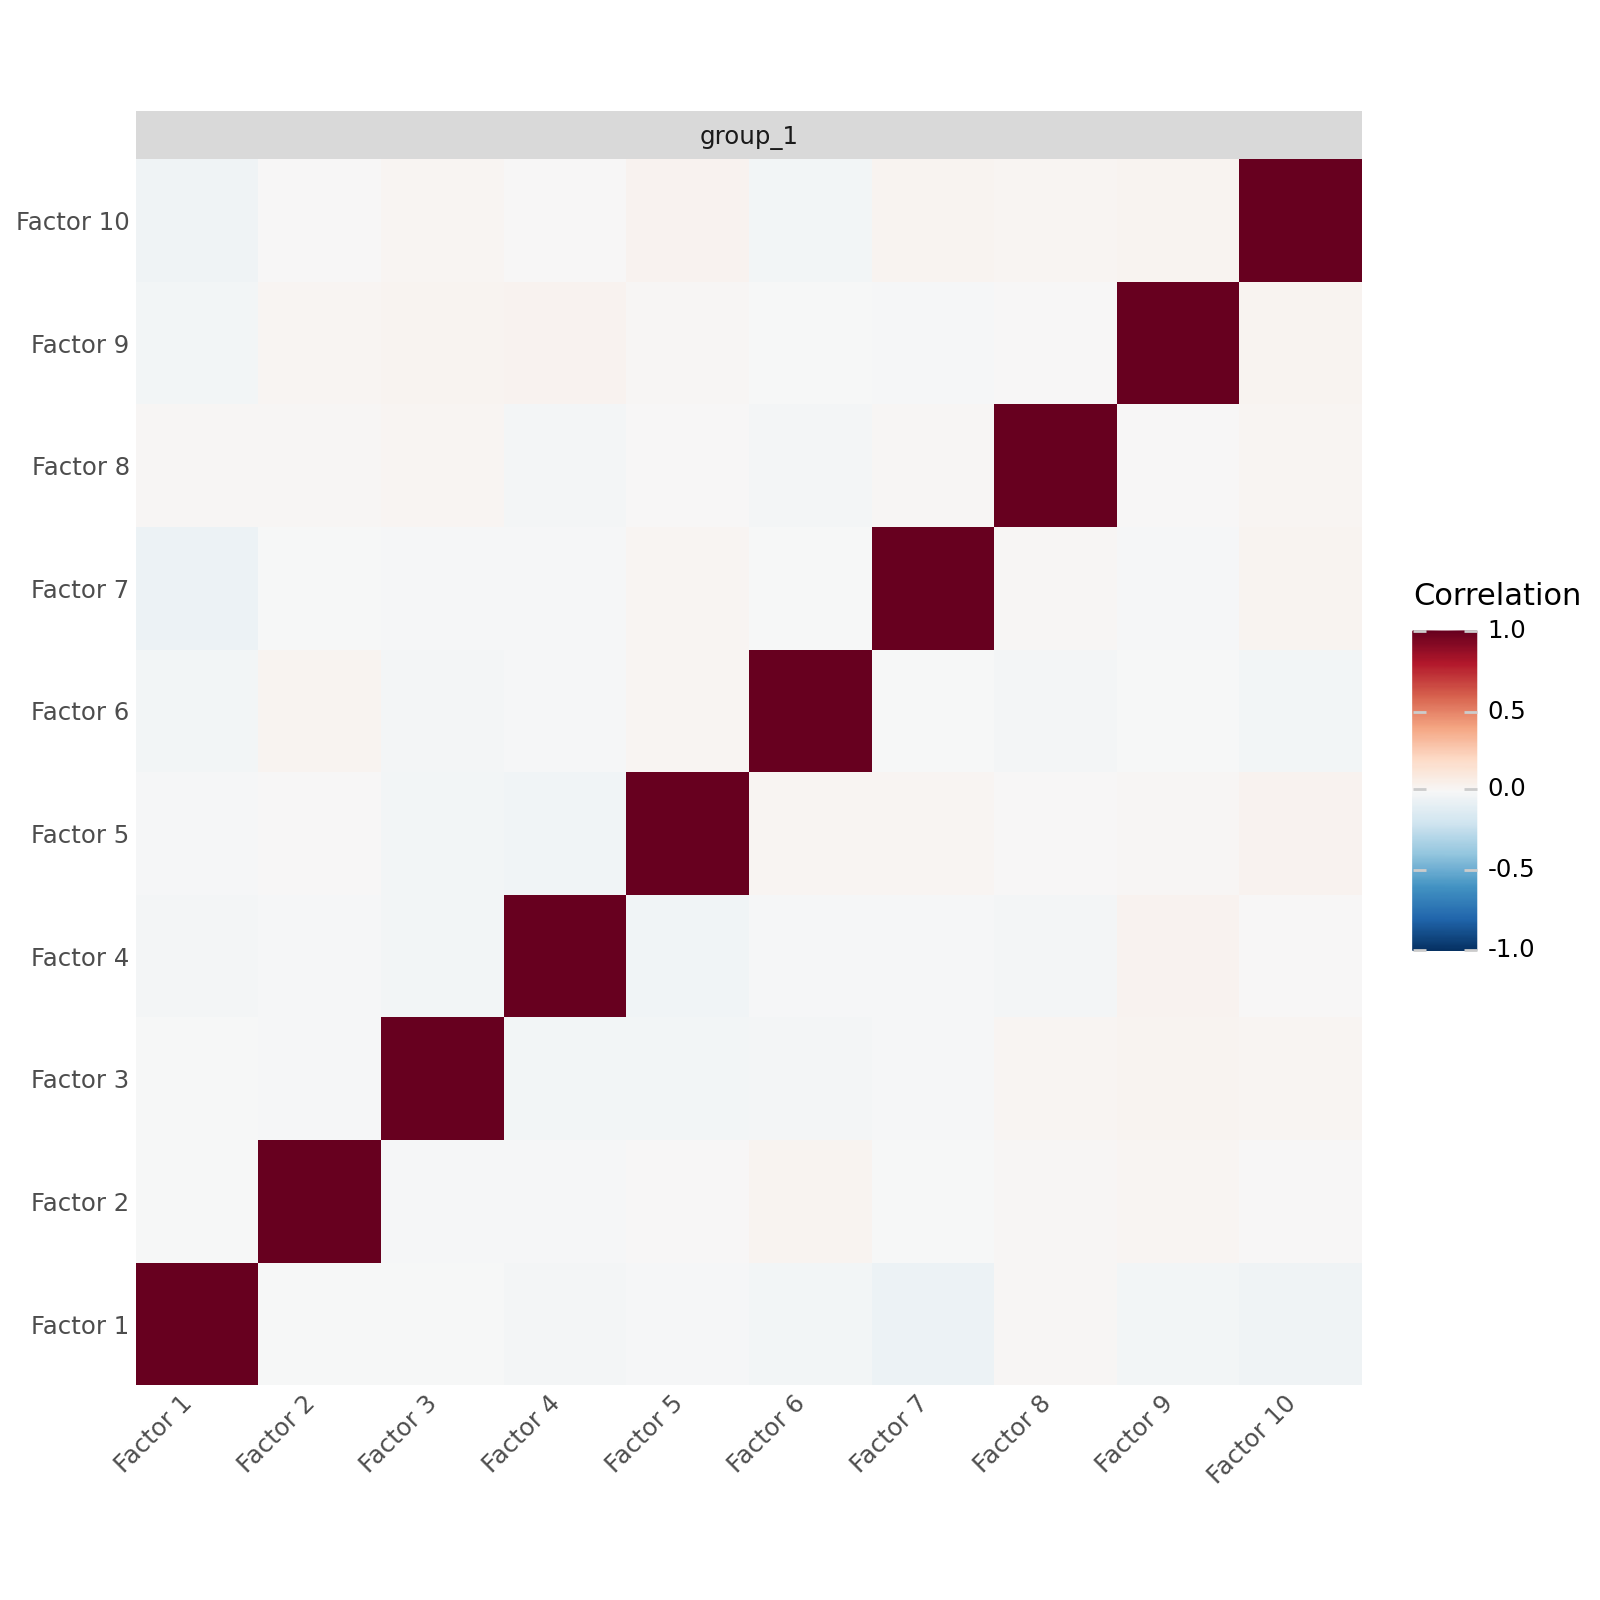

In [37]:
#Factor correlation
mfl.pl.factor_correlation(model)

In [38]:
def filter_factors(model, r2_thresh=0.99):
    r2_df = model.get_r2()["group_1"]
    r2_sorted = r2_df.sum(axis=1).sort_values(ascending=False)

    if r2_thresh < 1.0:
        r2_thresh = (r2_sorted.cumsum() / r2_sorted.sum() < r2_thresh).sum() + 1

    return r2_sorted.iloc[: int(r2_thresh)].index

In [39]:
factor_adata = model.get_factors("anndata")["group_1"][:, filter_factors(model)]

In [40]:
factor_adata

View of AnnData object with n_obs × n_vars = 4113 × 10
    obs: 'in_tissue', 'array_row', 'array_col', 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'mt_frac', 'celltype_niche', 'molecular_niche', 'cell_type'

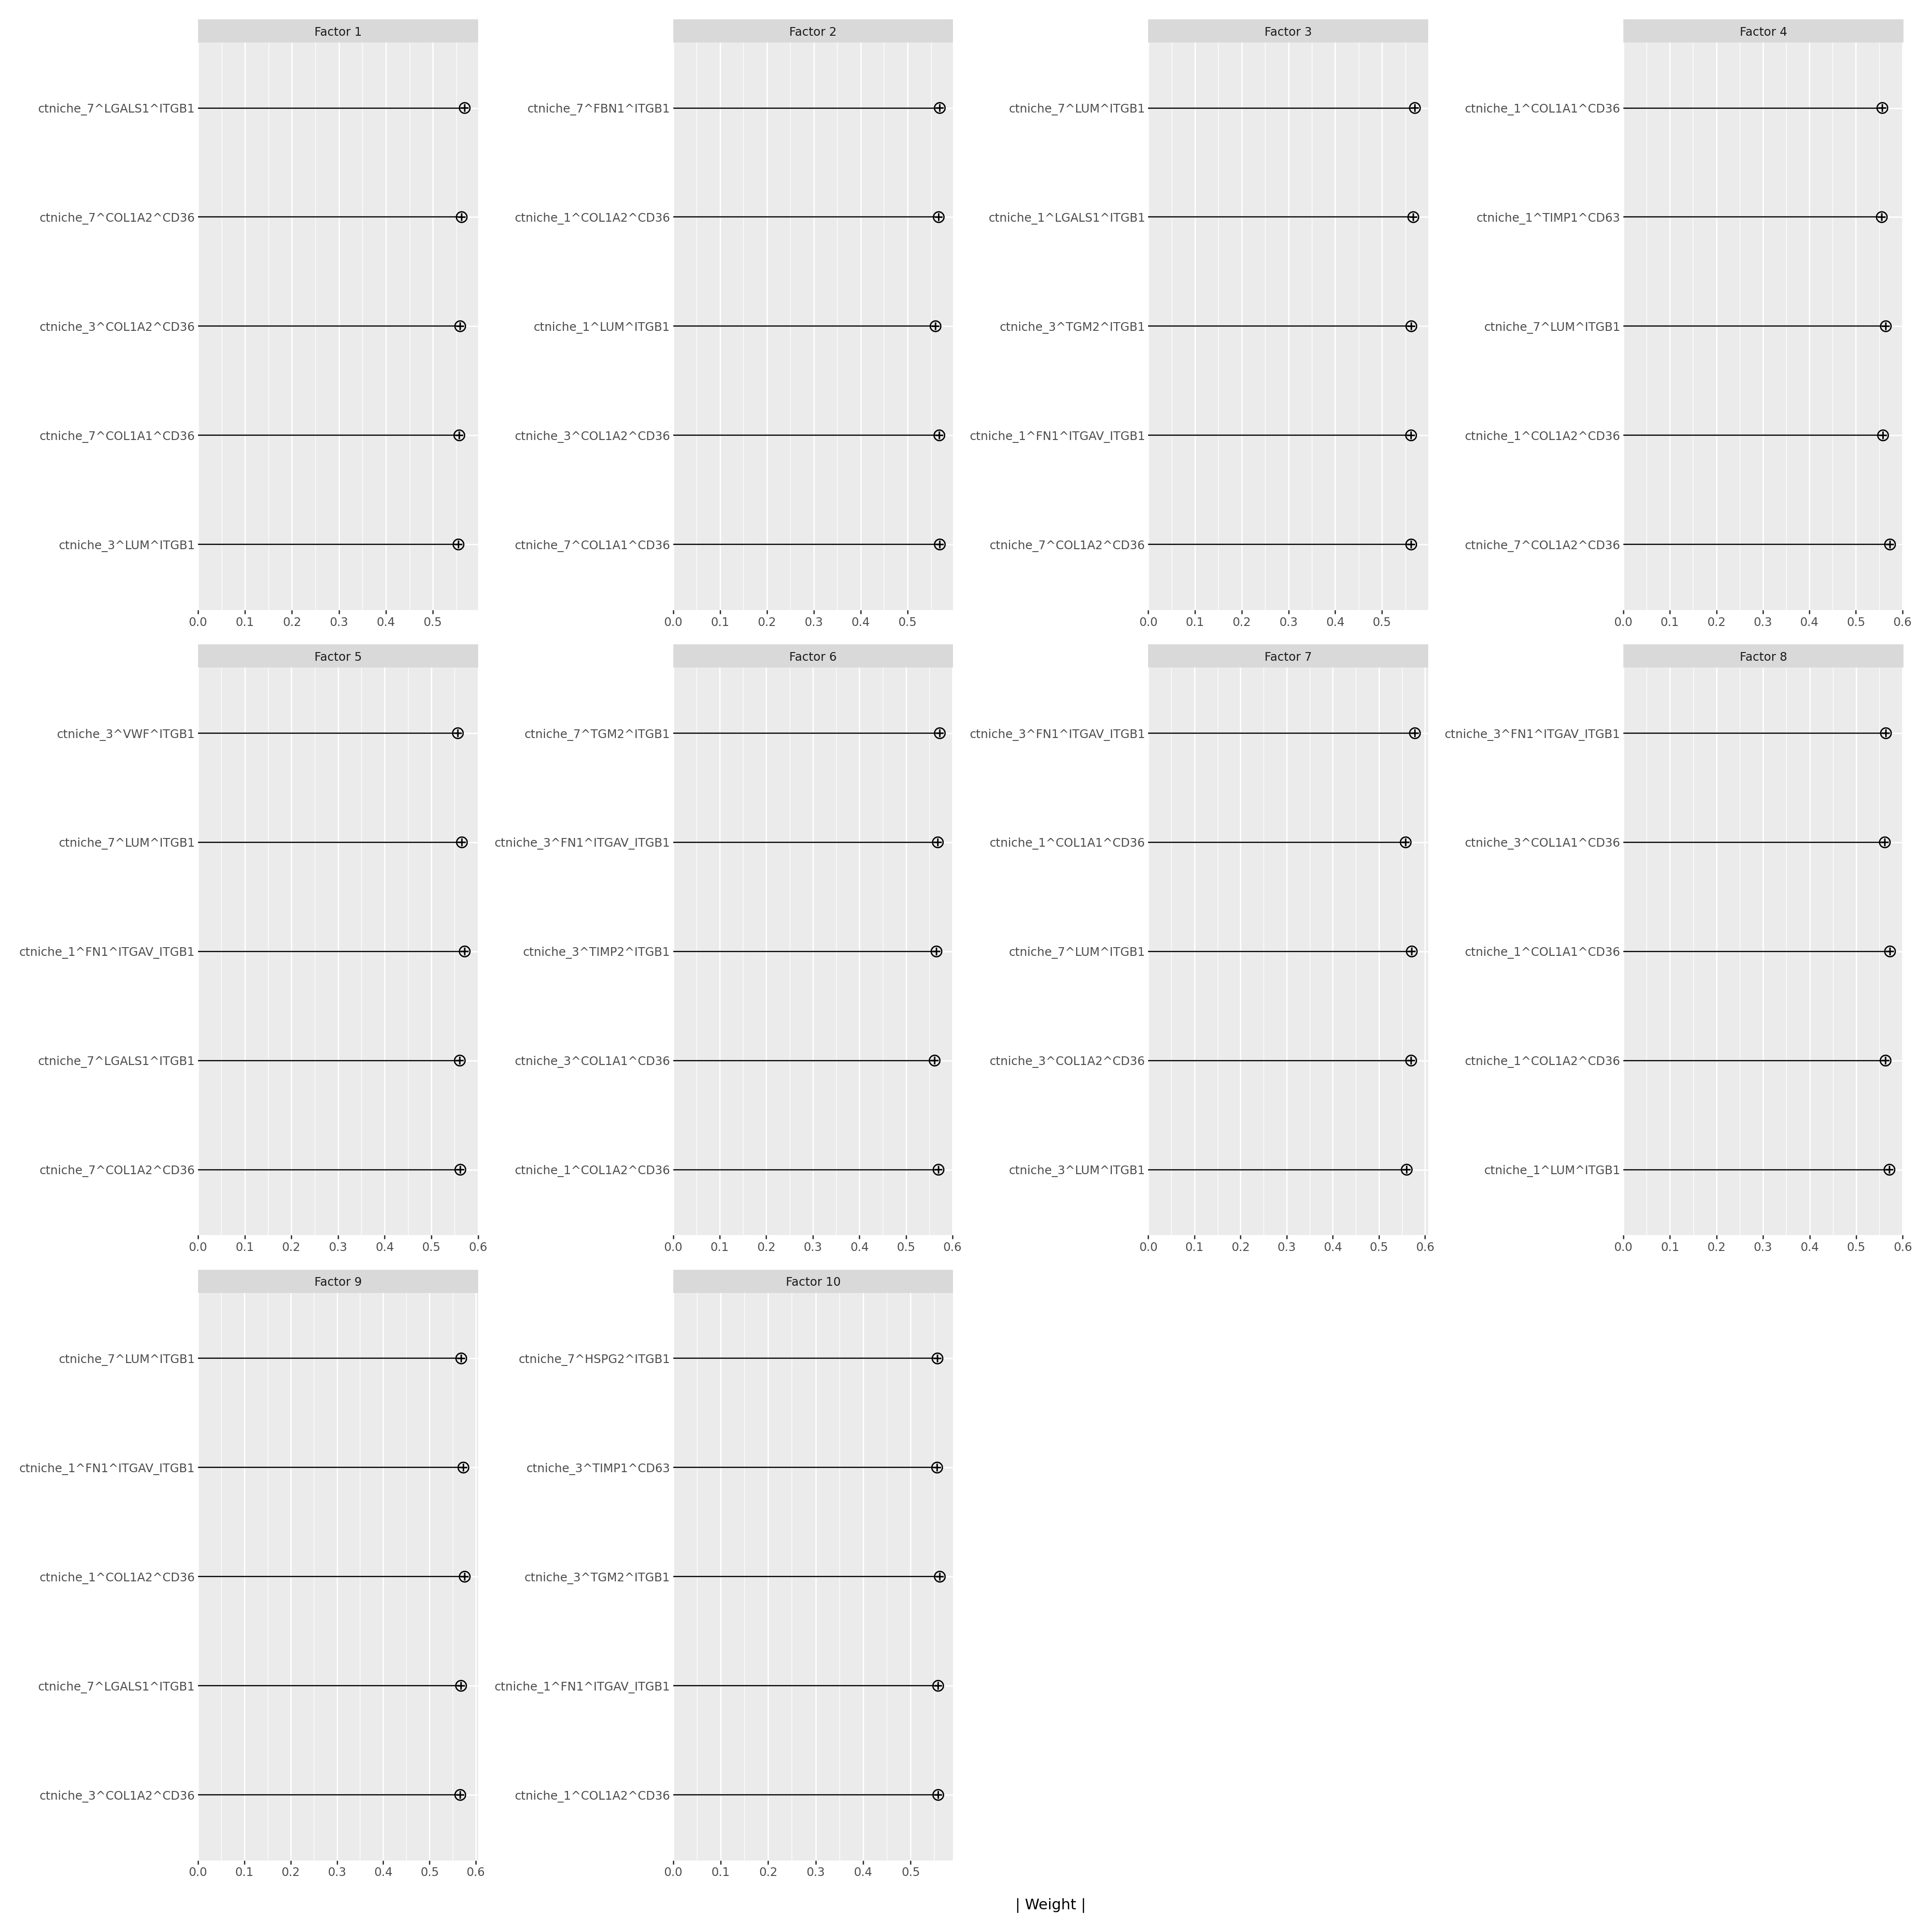

In [41]:
mfl.pl.top_weights(model, n_features=5, factors=None, figsize=(20, 20), nrow=None, ncol=None)

In [ ]:
mdata.obsm['X_MOFA'] = factor_adata.X

In [ ]:
mdata.obsm['X_MOFA']